# 中国省级逐时负荷的空间下推与电网节点映射

本notebook读取2015-2024年省级逐时合成负荷，用人口空间分布构造省内负荷权重，
再把每个网格分配到同省最近的最大连通图变电站。它保留省级逐时总量，不把人口
权重误解释为真实的城市、行业或电压等级负荷观测。

## 1. 运行环境与集中配置

`load_year`控制映射年份，`spatial_resolution_km`控制人口栅格聚合尺度。
`population_source`优先使用WorldPop；GeoNames仅是缺少完整栅格时的降级方案。

In [5]:
from pathlib import Path
import json
import re
from urllib.request import urlopen

from IPython.display import Markdown, display
from matplotlib.patches import Patch
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import xy

load_article_url = "https://www.nature.com/articles/s41597-026-07327-8"
load_figshare_doi = "https://doi.org/10.6084/m9.figshare.29832701"
load_figshare_api = "https://api.figshare.com/v2/articles/29832701"
load_file_path = Path("data/china_provincial_hourly_load_2015_2024.xlsx")
worldpop_url = (
    "https://data.worldpop.org/GIS/Population/Global_2000_2020_1km_UNadj/"
    "2020/CHN/chn_ppp_2020_1km_Aggregated_UNadj.tif"
)
worldpop_file_path = Path("data/chn_ppp_2020_1km_aggregated_unadj.tif")
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

load_year = 2024
spatial_resolution_km = 30
station_distance_review_km = 150
sample_provinces = {
    "Beijing": "北京市",
    "Shandong": "山东省",
    "Zhejiang": "浙江省",
    "Xinjiang": "新疆维吾尔自治区",
}
station_load_colormap = "turbo"
save_station_hourly_load = True
figure_size = (16, 12)
figure_dpi = 300

province_name_map = {
    "Beijing": "北京市", "Tianjin": "天津市", "Hebei": "河北省",
    "Shanxi": "山西省", "Inner Mongolia": "内蒙古自治区",
    "Liaoning": "辽宁省", "Jilin": "吉林省", "Heilongjiang": "黑龙江省",
    "Shanghai": "上海市", "Jiangsu": "江苏省", "Zhejiang": "浙江省",
    "Anhui": "安徽省", "Fujian": "福建省", "Jiangxi": "江西省",
    "Shandong": "山东省", "Henan": "河南省", "Hubei": "湖北省",
    "Hunan": "湖南省", "Guangdong": "广东省", "Guangxi": "广西壮族自治区",
    "Hainan": "海南省", "Chongqing": "重庆市", "Sichuan": "四川省",
    "Guizhou": "贵州省", "Yunnan": "云南省", "Tibet": "西藏自治区",
    "Shaanxi": "陕西省", "Gansu": "甘肃省", "Qinghai": "青海省",
    "Ningxia": "宁夏回族自治区", "Xinjiang": "新疆维吾尔自治区",
}


## 2. 下载并校验公开数据

省级负荷来自Scientific Data论文关联的Figshare工作簿，含2015-2024十张逐时表。
人口主数据是WorldPop 2020中国1 km人口计数栅格（CC BY 4.0）。GeoNames
`cities500.zip`只覆盖有名称的居民点，不能替代完整人口栅格。

In [6]:
def download_file(url, file_path):
    file_path.parent.mkdir(parents=True, exist_ok=True)
    with urlopen(url) as response, file_path.open("wb") as output:
        while chunk := response.read(1024 * 1024):
            output.write(chunk)


if not load_file_path.exists():
    try:
        with urlopen(load_figshare_api) as response:
            _figshare = json.load(response)
        _load_file = next(
            file for file in _figshare["files"]
            if file["name"].lower() == "data output.xlsx"
        )
        download_file(_load_file["download_url"], load_file_path)
    except Exception as error:
        raise RuntimeError(
            f"Figshare自动下载失败：{error}\n"
            f"请从 {load_figshare_doi} 下载Data output.xlsx并重命名为"
            f"{load_file_path.name}。"
        ) from error

if not worldpop_file_path.exists():
    download_file(worldpop_url, worldpop_file_path)

_load_sheet_by_year = {}
for _sheet_name in pd.ExcelFile(load_file_path, engine="openpyxl").sheet_names:
    _match = re.fullmatch(
        r"(20\d{2})(?:\s+load\s+curve)?", _sheet_name.strip(), re.IGNORECASE
    )
    if _match:
        _load_sheet_by_year[int(_match.group(1))] = _sheet_name

_missing_years = set(range(2015, 2025)) - set(_load_sheet_by_year)
if _missing_years:
    raise ValueError(f"负荷工作簿缺少年份sheet: {sorted(_missing_years)}")

with rasterio.open(worldpop_file_path) as _raster:
    population_source_summary = pd.Series({
        "source": "WorldPop 2020 UN-adjusted population count",
        "file": str(worldpop_file_path),
        "crs": str(_raster.crs),
        "native_pixel_size_degrees": abs(_raster.transform.a),
    }, name="value")

display(Markdown(f"[负荷论文]({load_article_url}) | [负荷数据]({load_figshare_doi})"))
display(population_source_summary)


[负荷论文](https://www.nature.com/articles/s41597-026-07327-8) | [负荷数据](https://doi.org/10.6084/m9.figshare.29832701)

source                       WorldPop 2020 UN-adjusted population count
file                         data/chn_ppp_2020_1km_aggregated_unadj.tif
crs                                                           EPSG:4326
native_pixel_size_degrees                                      0.008333
Name: value, dtype: object

## 3. 读取省级逐时负荷

本节只完成三件事：选择配置年份；把第一列解析为统一的逐小时时间戳；把
`Shandong (山东)` 一类双语列名统一为OSM使用的标准中文省名。原始数值单位为
每小时电量GWh；由于每个时间步恰好为一小时，其数值也等于该小时平均功率GW，
代码不做数值换算。


In [7]:
provincial_hourly_load = pd.read_excel(
    load_file_path,
    sheet_name=_load_sheet_by_year[load_year],
    index_col=0,
    parse_dates=[0],
)
provincial_hourly_load.index = pd.DatetimeIndex(
    pd.to_datetime(provincial_hourly_load.index, errors="coerce"),
    name="timestamp",
)
provincial_hourly_load.columns = [
    province_name_map.get(str(column).split(" (", 1)[0].strip())
    for column in provincial_hourly_load.columns
]
provincial_hourly_load = provincial_hourly_load.apply(
    pd.to_numeric, errors="coerce"
)

if (
    provincial_hourly_load.columns.isna().any()
    or provincial_hourly_load.shape[1] != 31
    or provincial_hourly_load.index.hasnans
    or not provincial_hourly_load.index.is_unique
    or provincial_hourly_load.isna().any().any()
):
    raise ValueError("省级负荷的省名、时间戳或数值未完整解析。")

provincial_hourly_load.attrs["unit"] = "GWh per hourly interval"
provincial_load_summary = pd.DataFrame({
    "hours": provincial_hourly_load.notna().sum(),
    "annual_energy_gwh": provincial_hourly_load.sum(),
    "peak_hourly_energy_gwh": provincial_hourly_load.max(),
}).sort_values("annual_energy_gwh", ascending=False)
display(provincial_load_summary)


,hours,annual_energy_gwh,peak_hourly_energy_gwh
广东省,8784,912100.0,153.624198
江苏省,8784,848700.0,139.975338
山东省,8784,832000.0,133.687060
浙江省,8784,678000.0,117.926214
内蒙古自治区,8784,519300.0,64.771632
河北省,8784,498700.0,82.410134
河南省,8784,432000.0,89.903155
新疆维吾尔自治区,8784,423300.0,59.679134
四川省,8784,401800.0,77.053194
安徽省,8784,359800.0,61.747532


## 4. 构造省内空间负荷权重

WorldPop的原生人口像元先按相邻像元分块汇总到配置的近似空间分辨率，再用网格
中心点关联省份。人口占比是透明、守恒的基线，但会低估人口较少而工商业负荷较高
的网格；夜间灯光、建成区/工业用地、GDP或已有网格电量产品可在此处替换为组合
权重。


In [8]:
def worldpop_grid(file_path, resolution_km):
    with rasterio.open(file_path) as raster:
        _population = raster.read(1, masked=True).filled(0).astype("float64")
        _factor = max(1, round(resolution_km))
        _rows = int(np.ceil(raster.height / _factor))
        _columns = int(np.ceil(raster.width / _factor))
        _population = np.pad(
            _population,
            ((0, _rows * _factor - raster.height),
             (0, _columns * _factor - raster.width)),
        ).reshape(_rows, _factor, _columns, _factor).sum(axis=(1, 3))
        _row, _column = np.nonzero(_population > 0)
        _x, _y = xy(
            raster.transform,
            _row * _factor + _factor / 2,
            _column * _factor + _factor / 2,
        )
    return gpd.GeoDataFrame(
        {
            "grid_id": [f"worldpop_{r}_{c}" for r, c in zip(_row, _column)],
            "population": _population[_row, _column],
        },
        geometry=gpd.points_from_xy(_x, _y),
        crs=raster.crs,
    )


## 5. 载入OSM电网拓扑

`osm_exp.ipynb`是电网拓扑的唯一来源。这里直接使用其中已经包含省份、经纬度和
最大连通图标记的`station_nodes_gdf`，不会再次给变电站关联省份。省界仅用于判断
WorldPop网格属于哪个省。


In [ ]:
from IPython.utils.capture import capture_output

_required_osm_objects = {
    "grid_topology", "grid_nodes_gdf", "station_nodes_gdf",
    "station_areas_gdf", "grid_branches_gdf", "province_polygons",
}
if not _required_osm_objects.issubset(globals()):
    with capture_output():
        get_ipython().run_line_magic("run", "./osm_exp.ipynb")

In [10]:
mainland_provinces = province_polygons[
    ~province_polygons["province_name"].isin([
        "香港特别行政区", "澳门特别行政区", "台湾省", "JD",
    ])
].to_crs("EPSG:4326")
load_station_nodes_gdf = station_nodes_gdf.loc[
    station_nodes_gdf["in_largest_connected_graph"]
    & station_nodes_gdf["province_intersection_matched"],
    [
        "node_uid", "station_name", "node_province_name",
        "node_longitude", "node_latitude", "geometry",
    ],
].copy()

grid_load_weights_gdf = gpd.sjoin(
    worldpop_grid(worldpop_file_path, spatial_resolution_km),
    mainland_provinces[["province_name", "geometry"]],
    predicate="within",
    how="inner",
).drop(columns="index_right")
grid_load_weights_gdf["province_population_share"] = (
    grid_load_weights_gdf["population"]
    / grid_load_weights_gdf.groupby("province_name")["population"].transform("sum")
)

_missing_load_provinces = set(provincial_hourly_load) - set(
    grid_load_weights_gdf["province_name"]
)
if _missing_load_provinces:
    raise ValueError(f"WorldPop空间数据缺少省份: {sorted(_missing_load_provinces)}")


## 6. 网格到同省最近变电站的映射

每个网格只在其所属省份内搜索最近的有效变电站节点，不再重新判断变电站省份，也
不做跨省兜底。距离超过配置阈值的映射仍保留以维持省级负荷守恒，但会被标记供
人工复核。


In [11]:
_mapping_parts = []
for _province_name, _grid in grid_load_weights_gdf.to_crs(metric_crs).groupby(
    "province_name"
):
    _stations = load_station_nodes_gdf.loc[
        load_station_nodes_gdf["node_province_name"].eq(_province_name),
        ["node_uid", "geometry"],
    ]
    if _stations.empty:
        raise ValueError(f"{_province_name}没有可用于负荷映射的变电站节点。")
    _mapping_parts.append(
        gpd.sjoin_nearest(
            _grid,
            _stations,
            how="left",
            distance_col="station_distance_m",
        )
        .sort_values(["grid_id", "station_distance_m"])
        .drop_duplicates("grid_id")
        .drop(columns="index_right")
    )

grid_load_weights_gdf = gpd.GeoDataFrame(
    pd.concat(_mapping_parts, ignore_index=True),
    geometry="geometry",
    crs=metric_crs,
)
grid_load_weights_gdf["requires_distance_review"] = (
    grid_load_weights_gdf["station_distance_m"]
    > station_distance_review_km * 1000
)

station_load_weights = (
    grid_load_weights_gdf.groupby(
        ["province_name", "node_uid"], as_index=False
    )
    .agg(
        population=("population", "sum"),
        assigned_grids=("grid_id", "size"),
        mean_station_distance_km=(
            "station_distance_m", lambda value: value.mean() / 1000
        ),
        maximum_station_distance_km=(
            "station_distance_m", lambda value: value.max() / 1000
        ),
    )
    .merge(
        load_station_nodes_gdf.drop(columns="geometry"),
        on="node_uid",
        how="left",
    )
)
station_load_weights["province_load_share"] = (
    station_load_weights["population"]
    / station_load_weights.groupby("province_name")["population"].transform("sum")
)

if not np.allclose(
    station_load_weights.groupby("province_name")["province_load_share"].sum(),
    1,
    atol=1e-9,
):
    raise ValueError("省内变电站负荷权重未闭合为1。")


## 7. 生成变电站逐时负荷并验证守恒

用省级逐时矩阵乘以省份-变电站权重矩阵。这样无需物化庞大的“小时×网格”表，
同时可以随时用`grid_load_at()`恢复任一时刻的网格负荷。

In [12]:
_station_weight_matrix = station_load_weights.pivot(
    index="province_name",
    columns="node_uid",
    values="province_load_share",
).fillna(0)
station_hourly_load = (
    provincial_hourly_load[_station_weight_matrix.index]
    @ _station_weight_matrix
)
station_hourly_load.columns.name = "node_uid"

def grid_load_at(timestamp):
    _grid = grid_load_weights_gdf.merge(
        provincial_hourly_load.loc[timestamp].rename("province_load_gwh"),
        left_on="province_name",
        right_index=True,
        how="left",
    )
    _grid["grid_load_gwh"] = (
        _grid["province_load_gwh"] * _grid["province_population_share"]
    )
    return _grid


_national_error = (
    station_hourly_load.sum(axis=1)
    - provincial_hourly_load[_station_weight_matrix.index].sum(axis=1)
).abs()
load_mapping_summary = pd.Series({
    "load_year": load_year,
    "hours": len(provincial_hourly_load),
    "provinces": len(_station_weight_matrix),
    "spatial_grid_points": len(grid_load_weights_gdf),
    "station_nodes_with_load": station_hourly_load.shape[1],
    "maximum_grid_station_distance_km": (
        grid_load_weights_gdf["station_distance_m"].max() / 1000
    ),
    "grids_requiring_distance_review": (
        grid_load_weights_gdf["requires_distance_review"].sum()
    ),
    "maximum_national_conservation_error_gwh": _national_error.max(),
}, name="value")
if _national_error.max() > 1e-6:
    raise ValueError("变电站逐时负荷与省级负荷总量不守恒。")
display(load_mapping_summary)


load_year                                  2.024000e+03
hours                                      8.784000e+03
provinces                                  3.100000e+01
spatial_grid_points                        1.365800e+04
station_nodes_with_load                    1.298000e+03
maximum_grid_station_distance_km           1.357552e+03
grids_requiring_distance_review            2.722000e+03
maximum_national_conservation_error_gwh    9.094947e-13
Name: value, dtype: float64

## 8. 保存映射并检查样例省份的逐时守恒

每个子图的彩色堆叠面积是该省全部变电站节点的逐时分配负荷，黑色实线是Excel
中的原始省级逐时负荷。两者重合表示网格分配和最近站点聚合在每个小时均保持总量
不变；颜色仅区分站点，不表示额外的连续数值。


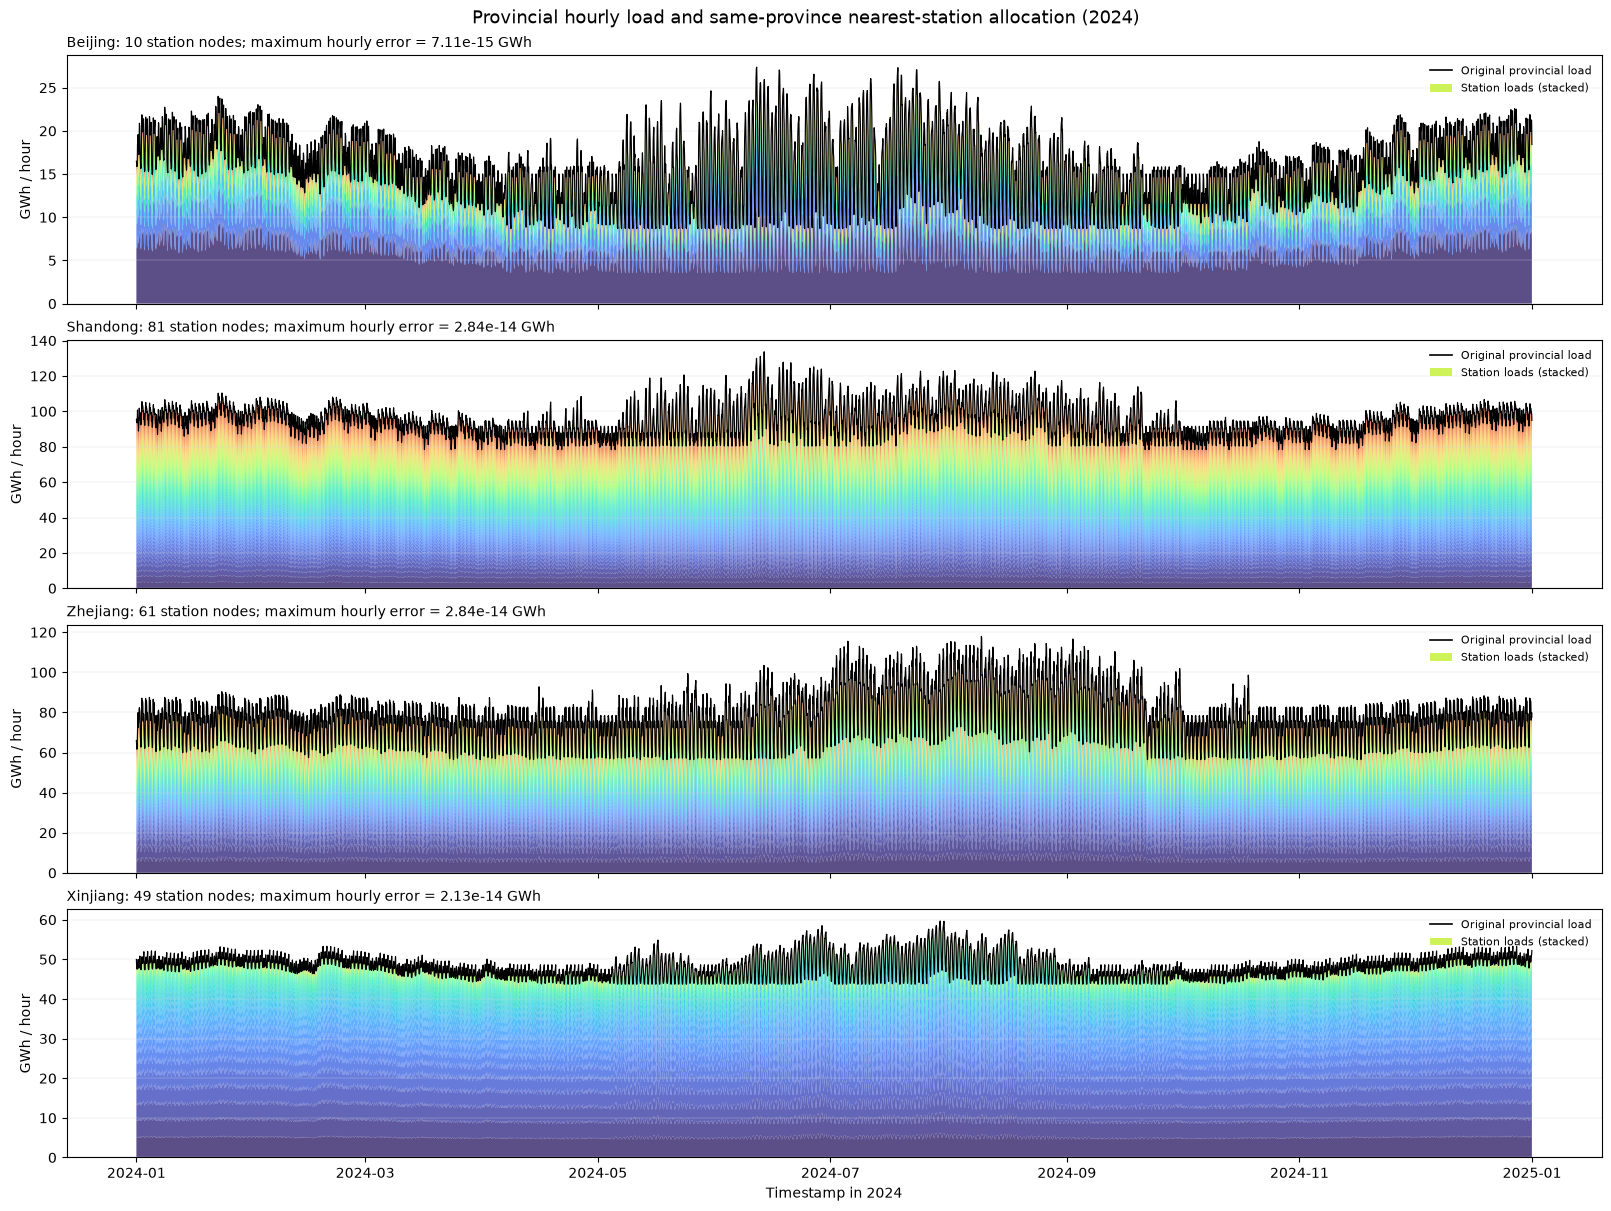

In [13]:
grid_load_weights_gdf.to_file(
    output_dir / "load_grid_station_mapping.gpkg",
    layer="grid_mapping",
    driver="GPKG",
)
station_load_weights.to_csv(
    output_dir / "station_load_weights.csv",
    index=False,
)
if save_station_hourly_load:
    station_hourly_load.to_parquet(
        output_dir / f"station_hourly_load_{load_year}.parquet"
    )

fig, axes = plt.subplots(
    len(sample_provinces),
    1,
    figsize=figure_size,
    sharex=True,
    constrained_layout=True,
)
for ax, (_province_label, _province_name) in zip(
    np.atleast_1d(axes), sample_provinces.items()
):
    _station_uids = (
        station_load_weights.query("province_name == @_province_name")
        .sort_values("province_load_share", ascending=False)["node_uid"]
    )
    _station_profiles = station_hourly_load[_station_uids]
    _colors = plt.get_cmap(station_load_colormap)(
        np.linspace(0.03, 0.97, len(_station_uids))
    )
    _ = ax.stackplot(
        _station_profiles.index,
        _station_profiles.T,
        colors=_colors,
        alpha=0.82,
        linewidth=0,
        zorder=1,
    )
    _ = ax.plot(
        provincial_hourly_load.index,
        provincial_hourly_load[_province_name],
        color="black",
        linewidth=0.85,
        label="Original provincial load",
        zorder=3,
    )
    _error = (
        _station_profiles.sum(axis=1)
        - provincial_hourly_load[_province_name]
    ).abs().max()
    _ = ax.set_title(
        f"{_province_label}: {len(_station_uids)} station nodes; "
        f"maximum hourly error = {_error:.2e} GWh",
        loc="left",
        fontsize=10,
    )
    _ = ax.set_ylabel("GWh / hour")
    _ = ax.grid(axis="y", color="#D1D5DB", linewidth=0.35, alpha=0.65)
    _ = ax.legend(
        handles=[
            plt.Line2D([], [], color="black", linewidth=1.2,
                       label="Original provincial load"),
            Patch(facecolor=plt.get_cmap(station_load_colormap)(0.55),
                  alpha=0.82, label="Station loads (stacked)"),
        ],
        loc="upper right",
        frameon=False,
        fontsize=8,
    )

_ = axes[-1].set_xlabel(f"Timestamp in {load_year}")
_ = fig.suptitle(
    f"Provincial hourly load and same-province nearest-station allocation ({load_year})",
    fontsize=13,
)
fig.savefig(
    output_dir / f"sample_province_station_load_{load_year}.png",
    dpi=figure_dpi,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
